# Assignment 7 — Pareto Front Visualisation & Regional Pathways

**Course:** EPA141A Model-Based Decision Making — Delft University of Technology  
**Model:** JUSTICE  

> **Pre-requisite:** Assignment 6 (MOEA Convergence & Reference Set).

---

## Learning Outcomes

After completing this assignment you will be able to:

1. Read and discuss **policy trade-offs** from a parallel-coordinates visualisation.
2. Interpret **regionalised emission control pathways** on a global map.

---

## Background

### Trade-off analysis

A solution is **Pareto-optimal** if you cannot improve one objective without worsening another. The **parallel-coordinates plot** is the standard visualisation for exploring trade-offs across 4+ objectives simultaneously:

- Each vertical axis represents one objective.
- Each line represents one non-dominated policy.
- A **crossing** between two adjacent axes reveals a trade-off: solutions that score well on one objective tend to score poorly on the other.
- Axes are oriented so that all objectives point to the same direction of preference, for instance **up = better** on every axis, making crossings immediately visible.

### Regional emission control rates

The JUSTICE model assigns an **emission control rate (ECR)** to each of the 57 RICE50 world regions. ECR ranges from 0 (no abatement) to 1 (full decarbonisation). The RBF policy computes the ECR for each region based on the current climate state (temperature and its rate of change).

Visualising the ECR at the end of the simulation horizon on a world map reveals **which regions are expected to decarbonise most aggressively** under each policy, and how this varies between policies.

---

## Overview

Starting from the reference set saved in Assignment 6, you will:

1. **Visualise the Pareto front** with a parallel-coordinates plot showing all four objectives.
2. **Map regional ECR pathways** by re-running JUSTICE with four of your selected policies and plotting the end-of-horizon ECR per RICE50 region on a world map.

## Setup — Imports and configuration

The cell below imports all required packages, applies the Python 3.14 compatibility patch for `matplotlib.path.Path`, and loads the cross-seed reference set produced in Assignment 6.

In [42]:
# ── Standard imports ──────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import os, sys, json, glob, copy
import numpy as np
import pandas as pd
import matplotlib.path as _mpath

def _fixed_path_deepcopy(self, memo):
    cls   = type(self)
    verts = copy.deepcopy(self.vertices, memo)
    codes = copy.deepcopy(self.codes, memo) if self.codes is not None else None
    new   = cls.__new__(cls)
    new.__init__(verts, codes)
    return new

_mpath.Path.__deepcopy__ = _fixed_path_deepcopy

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    import matplotlib
    matplotlib.use("Agg")

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})


# ── EMA Workbench ─────────────────────────────────────────────────────────────
from ema_workbench.em_framework.optimization import (
    epsilon_nondominated,
    PlatypusProblem,
)
from platypus import Real

# ── Geopandas for maps ───────────────────────────────────────────────────────
import geopandas as gpd

# ── Path setup ────────────────────────────────────────────────────────────────
try:
    _NOTEBOOK_DIR = os.path.dirname(os.path.abspath(__vsc_ipynb_file__))
except NameError:
    _NOTEBOOK_DIR = os.path.abspath('.')
_JUSTICE_ROOT = os.path.normpath(os.path.join(_NOTEBOOK_DIR, "../JUSTICE-main"))

if _JUSTICE_ROOT not in sys.path:
    sys.path.insert(0, _JUSTICE_ROOT)

os.chdir(_JUSTICE_ROOT)

RESULTS_ROOT = os.path.normpath(os.path.join(_NOTEBOOK_DIR, "results"))
_PLOTS_DIR  = os.path.join(_NOTEBOOK_DIR, "plots")
os.makedirs(_PLOTS_DIR, exist_ok=True)

# ── Objective metadata ────────────────────────────────────────────────────────
OBJECTIVE_COLS  = ["welfare", "fraction_above_threshold",
                   "welfare_loss_damage", "welfare_loss_abatement"]
MAXIMIZE_COLS   = ["welfare_loss_damage", "welfare_loss_abatement"]
MINIMIZE_COLS   = ["welfare", "fraction_above_threshold"]
OBJECTIVE_LABELS = {
    "welfare":                  "Welfare loss\n(MINIMIZE)",
    "fraction_above_threshold": "Fraction above\n2°C in 2100\n(MINIMIZE)",
    "welfare_loss_damage":      "Welfare loss\nfrom damage\n(MAXIMIZE)",
    "welfare_loss_abatement":   "Welfare loss\nfrom abatement\n(MAXIMIZE)",
}

print(f"JUSTICE root : {_JUSTICE_ROOT}")
print(f"Results root : {RESULTS_ROOT}")
print(f"DEAP hv      : OK")
print(f"geopandas    : {gpd.__version__}")
print("Matplotlib deepcopy patch applied.")

JUSTICE root : c:\Users\matsm\epa141a\JUSTICE-main
Results root : c:\Users\matsm\epa141a\assignments_ema\results
DEAP hv      : OK
geopandas    : 1.1.3
Matplotlib deepcopy patch applied.


## Load the Reference Set

This cell loads the Pareto-optimal reference set you generated in Assignment 6.

> **Before running:** replace `<name_of_your_reference_set>` with the actual filename of your saved reference set.


In [43]:
# ── Load grand reference set from Assignment 6 ────────────────────────────────

ref_path = os.path.join(RESULTS_ROOT, "reference_set_UTILITARIAN.csv")

if not os.path.exists(ref_path):
    raise FileNotFoundError(
        f"Reference set not found: {ref_path}\n"
        "Run Assignment 6 (Steps 1-3) first to build and save the reference set."
    )

ref_set = pd.read_csv(ref_path)
ref_set.columns = [c.replace(" ", "_") for c in ref_set.columns]
ref_set = ref_set[ref_set["welfare"] < 1e5].reset_index(drop=True)


print(f"Reference set loaded: {len(ref_set)} solutions × {len(ref_set.columns)} columns")
print(f"\nObjective statistics:")
print(ref_set[OBJECTIVE_COLS].describe().round(3).to_string())

Reference set loaded: 26 solutions × 248 columns

Objective statistics:
       welfare  fraction_above_threshold  welfare_loss_damage  welfare_loss_abatement
count   26.000                    26.000               26.000                  26.000
mean   106.908                     0.765             3656.652               13776.695
std      0.095                     0.177                7.325                3615.998
min    106.817                     0.500             3638.895               12723.148
25%    106.829                     0.600             3653.605               12773.654
50%    106.896                     0.700             3656.683               12887.614
75%    106.963                     0.900             3662.141               12950.977
max    107.138                     1.000             3667.270               30676.845


---

## Step 1 — Pareto Front Visualisation & Trade-off Discussion


### Parallel-Coordinates Plot

Create a **parallel-coordinates plot** of your reference set that lets you
visually compare all solutions across every objective at once.

**What to produce**

- One line per solution in the reference set; every axis represents one objective.
- All axes should point to the same direction of preference for instance..if **upward = better**, you would normalise your data accordingly
  (invert minimisation objectives after scaling to [0, 1]).
- Colour the lines by one objective of your choice to reveal trade-off patterns.
- Highlight four solutions, based on your criteria,  using thick, distinctly coloured lines and a legend.
- Add a colour bar, labelled axes, and a title.

**Useful resources**

- [`ema_workbench` built-in parallel coordinates](https://emaworkbench.readthedocs.io/en/latest/ema_documentation/analysis/parcoords.html)
  — the quickest route; wraps matplotlib and handles normalisation for you.

- [Pandas `DataFrame.plot`](https://pandas.pydata.org/docs/reference/api/pandas.plotting.parallel_coordinates.html)



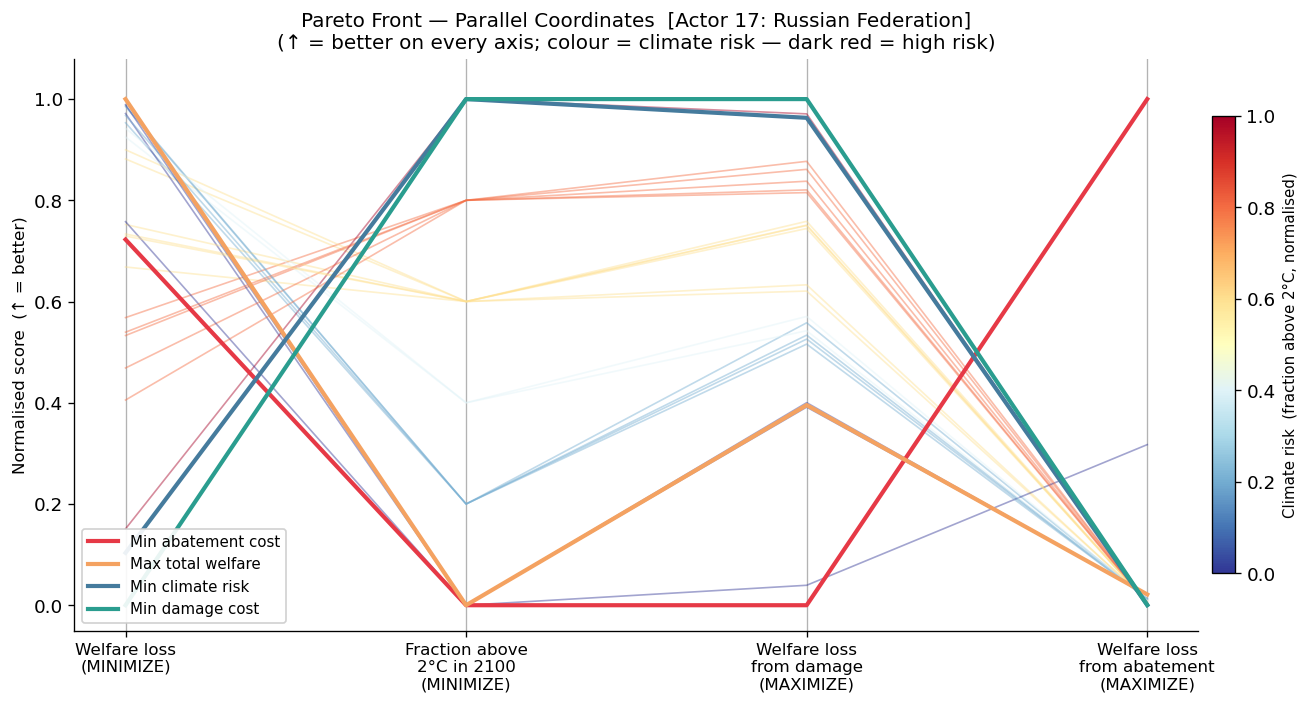

In [44]:
# ── Parallel-coordinates plot — framed from Russia's perspective ──────────────
fig, ax = plt.subplots(figsize=(12, 6))

# Normalise objectives to [0, 1]; invert MINIMIZE cols so up = better on every axis
norm_df = ref_set[OBJECTIVE_COLS].copy()
for col in OBJECTIVE_COLS:
    lo, hi = norm_df[col].min(), norm_df[col].max()
    norm_df[col] = (norm_df[col] - lo) / (hi - lo + 1e-15)
    if col in MINIMIZE_COLS:
        norm_df[col] = 1 - norm_df[col]

x_positions = np.arange(len(OBJECTIVE_COLS))

# Colour by climate risk — dark red = high risk, blue = low risk
cmap = cm.RdYlBu_r
frac_vals = norm_df["fraction_above_threshold"].values
c_norm = Normalize(vmin=frac_vals.min(), vmax=frac_vals.max())

for i, row in norm_df.iterrows():
    y = [row[col] for col in OBJECTIVE_COLS]
    ax.plot(x_positions, y,
            color=cmap(c_norm(row["fraction_above_threshold"])),
            alpha=0.45, lw=1.0, zorder=2)

# Anchor policies
idx_min_abatement  = ref_set["welfare_loss_abatement"].idxmax()
idx_max_welfare    = ref_set["welfare"].idxmin()
idx_min_climate    = ref_set["fraction_above_threshold"].idxmin()
idx_min_damage     = ref_set["welfare_loss_damage"].idxmax()

anchors = {
    "Min abatement cost": (idx_min_abatement,  "#e63946"),
    "Max total welfare":  (idx_max_welfare,     "#f4a261"),
    "Min climate risk":   (idx_min_climate,     "#457b9d"),
    "Min damage cost":    (idx_min_damage,      "#2a9d8f"),
}

legend_lines = []
for label, (idx, color) in anchors.items():
    y = [norm_df.loc[idx, col] for col in OBJECTIVE_COLS]
    ax.plot(x_positions, y, color=color, lw=2.5, zorder=5)
    legend_lines.append(Line2D([0], [0], color=color, lw=2.5, label=label))

# Styling
for x in x_positions:
    ax.axvline(x, color="0.7", lw=0.8, zorder=1)

ax.set_xticks(x_positions)
ax.set_xticklabels([OBJECTIVE_LABELS[c] for c in OBJECTIVE_COLS], fontsize=10)
ax.set_ylim(-0.05, 1.08)
ax.set_ylabel("Normalised score  (↑ = better)", fontsize=10)
ax.set_title(
    "Pareto Front — Parallel Coordinates  [Actor 17: Russian Federation]\n"
    "(↑ = better on every axis; colour = climate risk — dark red = high risk)",
    fontsize=12,
)

sm = cm.ScalarMappable(cmap=cmap, norm=c_norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.01, shrink=0.8)
cbar.set_label("Climate risk  (fraction above 2°C, normalised)", fontsize=9)

ax.legend(handles=legend_lines, loc="lower left", fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.savefig(os.path.join(_PLOTS_DIR, "parcoords_reference_set.png"), dpi=150, bbox_inches="tight")
plt.show()

### Trade-off Discussion

Interpret your parallel-coordinates plot. Your answer should cover:

1. **Pairwise trade-offs** — for each pair of adjacent axes, does a crossing appear? What does it mean for the relationship between those two objectives?
2. **Dominant trade-off** — which pair shows the sharpest conflict? 
3. **Synthesis** — in 2 sentences, what is the fundamental tension in this problem as revealed by the Pareto front?


**Why these 4 anchor policies**

Russia's mandate has two layers: what they actually want, and what they publicly claim to want. The anchors reflect both.

**Min abatement cost** — This is Russia's core self-interest. Russia is a fossil fuel exporter; high emission control rates directly threaten their economy. The policy with the lowest abatement burden represents the point on the Pareto front most favorable to Russia's economic position. This is the policy Russia would push for in negotiations.

**Max total welfare** — Russia's actor file explicitly says their public welfare lens is maximizing total welfare across all regions. This gives them a defensible, non-selfish-sounding argument in negotiations. Highlighting this anchor lets you show where that policy sits on the Pareto front relative to Russia's preferred policy — if they're close, Russia's argument is consistent; if they're far apart, it reveals the tension between Russia's stated and actual goals.

**Min climate risk** — This is what climate-vulnerable nations push for. Highlighting it shows the sharpest contrast with Russia's preferred policy, making the trade-off between climate safety and abatement cost visually obvious. In the final report this line is the counter-argument — you acknowledge it exists on the Pareto front but argue against it from Russia's position.

**Min damage cost** — A middle-ground anchor. It avoids maximum climate damage without necessarily requiring the aggressive abatement that Russia opposes. Useful for showing that there are policies between Russia's ideal and the climate-risk extreme, which matters when arguing for compromise positions in negotiations.

---

**Why color by climate risk**

The colormap colors lines by `fraction_above_threshold` — the fraction of regions exceeding 2°C in 2100. This is the central dimension of conflict in the negotiations: climate-vulnerable actors demand low climate risk (blue lines) while Russia's preferred policy accepts higher risk (red lines). Coloring by climate risk makes that conflict immediately visible across all four axes simultaneously — you can see at a glance what accepting more climate risk buys in terms of lower abatement cost and where the crossing patterns appear. Coloring by abatement cost was considered but rejected because that objective already has its own axis; the colormap adds more value by revealing a dimension that isn't already directly readable from a single axis position.

---

## Step 2 — Regional Emission Control Rate (ECR) Pathways

During the optimisation, each Pareto-optimal solution was stored as a set of
**RBF parameters** (centers, radii, weights) plus its four objective values.
The parameters encode *how* the policy responds to the climate state — but the
full regional detail (which region gets how much emission control, and when) was
never saved.

The following cell takes care of that.. 

**1. Import tools**
Loads all the components needed to run the JUSTICE model — the model itself, the RBF policy structure, time settings, region data, and constraint logic.

**2. Load your config file**
Opens your config file (make sure you specify your config file in the cell) and reads the model settings (start/end year, timestep size, scenario index, etc.) so everything is consistent with how the optimisation was originally run.

**3. Set up constants**
Calculates how many timesteps and regions the model has, and stores the temperature bounds used for scaling later.

**4. Define a helper function: `run_policy_ecr(policy_row)`**
When called with a single policy (one row from the reference set), this function:

- **Rebuilds the RBF** — extracts the centers, radii, and weights stored in that row, recreating the decision rule that was optimised.
- **Sets up a constraint** — limits how fast emission control can grow each year so the model behaves realistically. 
- **Initialises JUSTICE** — sets up the model with the same scenario and assumptions used during optimisation.
- **Runs the model one timestep at a time** — at each step it applies the constraint, advances the model, reads the resulting global temperature, scales it to [0, 1], and feeds it back into the RBF to decide the next timestep's emission control rate. The RBF is essentially a rule: given the climate state right now, apply this much control to each region. It's static in its parameters, but its output varies because the climate state it reads changes at every step. You're re-running the policy forward through time to recover the full regional detail that wasn't saved during optimisation
- **Returns** the mean emission control rate across regions over time, plus the full model output.

**5. Select your policies**
Filters the reference set to the objective columns, then asks you to pick one policy per objective using for instance `.idxmin()` or `.idxmax()`, but  the idea is to use the index pointing to your selected policies.

**6. Print a summary**
Prints each selected policy's objective values so you can verify your selection before running.

**7. Run the model**
Calls `run_policy_ecr()` once per selected policy to get its full emission control trajectory.


In [45]:
# ── JUSTICE imports ───────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

from justice.model import JUSTICE
from justice.util.data_loader import DataLoader
from justice.util.enumerations import (
    Abatement, DamageFunction, Economy, WelfareFunction
)
from justice.util.emission_control_constraint import EmissionControlConstraint
from justice.util.model_time import TimeHorizon
from solvers.emodps.rbf import RBF

# ── Model constants ─────────────────────────

#TODO:
#Before you begin: Update the path in the cell below 
#to point to the config file you created previously. 
#Make sure it reflects the scenario and settings you have been working
#with throughout. 

with open(os.path.join(_NOTEBOOK_DIR, "../config/config_student.json")) as fh:
    _cfg = json.load(fh)

_time_horizon = TimeHorizon(
    start_year            = _cfg["start_year"],
    end_year              = _cfg["end_year"],
    data_timestep         = _cfg["data_timestep"],
    timestep              = _cfg["timestep"],
)
N_TIMESTEPS    = len(_time_horizon.model_time_horizon)
N_REGIONS      = len(DataLoader().REGION_LIST)
REGION_LIST    = list(DataLoader().REGION_LIST)
N_INPUTS_RBF   = _cfg["n_inputs"]
N_RBFS         = _cfg["n_inputs"] + 2
SCENARIO       = _cfg["reference_ssp_rcp_scenario_index"]
EC_START_TS    = _time_horizon.year_to_timestep(
    year=_cfg["emission_control_start_year"],
    timestep=_cfg["timestep"],
)
_MAX_TEMP, _MIN_TEMP = 16.0, 0.0
_MAX_DIFF, _MIN_DIFF = 2.0,  0.0

# ── Helper: run JUSTICE for one policy row ────────────────────────────────────
def run_policy_ecr(policy_row, n_ensemble=1):
    rbf = RBF(n_rbfs=N_RBFS, n_inputs=N_INPUTS_RBF, n_outputs=N_REGIONS)
    c_shape, r_shape, w_shape = rbf.get_shape()

    centers = np.array([policy_row[f"center_{i}"] for i in range(c_shape[0])])
    radii   = np.array([policy_row[f"radii_{i}"]  for i in range(r_shape[0])])
    weights = np.array([policy_row[f"weights_{i}"] for i in range(w_shape[0])])
    rbf.set_decision_vars(np.concatenate([centers, radii, weights]))

    constraint = EmissionControlConstraint(
        max_annual_growth_rate=0.04,
        emission_control_start_timestep=EC_START_TS,
        min_emission_control_rate=0.01,
    )

    ensemble_indices = list(np.linspace(1, 1000, max(n_ensemble, 10), dtype=int))[:n_ensemble]

    model = JUSTICE(
        scenario=SCENARIO,
        climate_ensembles=ensemble_indices,
        economy_type=Economy.NEOCLASSICAL,
        damage_function_type=DamageFunction.KALKUHL,
        abatement_type=Abatement.ENERDATA,
        social_welfare_function_type=WelfareFunction.UTILITARIAN.value[0],
    )
    no_ens = model.no_of_ensembles

    ecr             = np.zeros((N_REGIONS, N_TIMESTEPS, no_ens))
    constrained_ecr = np.zeros_like(ecr)
    prev_temp = 0.0
    diff      = 0.0

    for t in range(N_TIMESTEPS):
        constrained_ecr[:, t, :] = constraint.constrain_emission_control_rate(
            ecr[:, t, :], t, allow_fallback=False
        )
        model.stepwise_run(
            emission_control_rate=constrained_ecr[:, t, :],
            timestep=t,
            endogenous_savings_rate=True,
        )
        data = model.stepwise_evaluate(timestep=t)
        temp = data["global_temperature"][t, :]

        if t % 5 == 0:
            diff      = temp - prev_temp
            prev_temp = temp

        scaled_temp = (temp - _MIN_TEMP) / (_MAX_TEMP - _MIN_TEMP)
        scaled_diff = (diff - _MIN_DIFF) / (_MAX_DIFF - _MIN_DIFF)

        if t < N_TIMESTEPS - 1:
            ecr[:, t + 1, :] = rbf.apply_rbfs(np.array([scaled_temp, scaled_diff]))

    datasets = model.evaluate()
    ecr_mean = constrained_ecr.mean(axis=2)
    return ecr_mean, datasets


# ── TODO: Select your  policies ────────────────────────────────────
# Use the same policies you highlighted in your parallel-coordinates plot.
# Replace each line below with the appropriate indeces. 

obj_ref = ref_set[OBJECTIVE_COLS]

idx_min_abatement = obj_ref["welfare_loss_abatement"].idxmax()
idx_max_welfare   = obj_ref["welfare"].idxmin()
idx_min_climate   = obj_ref["fraction_above_threshold"].idxmin()
idx_min_damage    = obj_ref["welfare_loss_damage"].idxmax()

anchors = {
    "Min abatement cost": idx_min_abatement,
    "Max total welfare":  idx_max_welfare,
    "Min climate risk":   idx_min_climate,
    "Min damage cost":    idx_min_damage,
}

print("Selected policies from Pareto reference set:\n")
for label, idx in anchors.items():
    print(f"  {label}")
    print(obj_ref.loc[idx].round(3).to_string(index=True))
    print()

# ── Run JUSTICE for each anchor ───────────────────────────────────────────────
print("Running JUSTICE model for all selected policies ...")
ecr_min_abatement, _ = run_policy_ecr(ref_set.loc[idx_min_abatement], n_ensemble=1)
ecr_max_welfare,   _ = run_policy_ecr(ref_set.loc[idx_max_welfare],   n_ensemble=1)
ecr_min_climate,   _ = run_policy_ecr(ref_set.loc[idx_min_climate],   n_ensemble=1)
ecr_min_damage,    _ = run_policy_ecr(ref_set.loc[idx_min_damage],    n_ensemble=1)
print("Done.")

Selected policies from Pareto reference set:

  Min abatement cost
welfare                       106.906
fraction_above_threshold        1.000
welfare_loss_damage          3638.895
welfare_loss_abatement      30676.845

  Max total welfare
welfare                       106.817
fraction_above_threshold        1.000
welfare_loss_damage          3650.114
welfare_loss_abatement      13105.838

  Min climate risk
welfare                       107.105
fraction_above_threshold        0.500
welfare_loss_damage          3666.221
welfare_loss_abatement      12729.001

  Min damage cost
welfare                       107.138
fraction_above_threshold        0.500
welfare_loss_damage          3667.270
welfare_loss_abatement      12730.371

Running JUSTICE model for all selected policies ...
Done.


### Preparing the Geographic Data

Run the cell below almost as-is (just update the `ecr_end` keys to match your selected policy labels).

**What it does:**

**1. Build a country: RICE50 lookup table**
The JUSTICE model groups the world into 57 aggregate regions (RICE50) rather than ~180 individual countries. To draw a world map, we need to go the other way — start from country shapes and colour each country according to the RICE50 region it belongs to. This step builds that link by reading a lookup table that says, for example, "Angola, Benin, Botswana, ... all belong to region rsaf."

The lookup uses each country's standard 3-letter ISO code (e.g. FRA for France). However, the world map shapefile we use here stores a few countries with the placeholder code '-99' instead of their real ISO code — so the lookup fails for them. The fallback simply matches those countries by name instead.

**2. Take an end-of-horizon snapshot**
From the full ECR time series computed in the previous cell, it extracts only
the **final timestep** — one ECR value per region per selected policy. This single
number summarises how aggressively each region is controlling emissions at the
end of the simulation under that policy.

**3. Attach ECR values to a world map**
It loads a world map (one shape per country), assigns each country to its RICE50 region, and attaches the ECR value to it. Countries that belong to the same RICE50 region are then merged into one shape, giving 57 regional polygons ready to be coloured in the next cell.

The output `regions_gdf` is a GeoDataFrame with 57 rows, ready to plot.


In [46]:
# ── Map world countries to RICE50 regions via ISO-3166 codes ─────────────────
import importlib.util, pathlib, json as _json

_rice50_dict_path = os.path.join(_JUSTICE_ROOT, "data", "input", "rice50_regions_dict.json")
with open(_rice50_dict_path) as _f:
    _rice50_dict = _json.load(_f)

iso_to_rice50 = {
    iso: region
    for region, isos in _rice50_dict.items()
    for iso in isos
}

_name_fallback = {
    "France":     "fra",
    "Norway":     "nor",
    "Kosovo":     "oeu",
    "N. Cyprus":  "tur",
    "Somaliland": "rsaf",
}

# ── Extract end-of-horizon ECR snapshot ───────────────────────────────────────
t_end     = ecr_min_abatement.shape[1] - 1
snap_year = int(_time_horizon.model_time_horizon[t_end])
print(f"End-of-horizon snapshot: timestep {t_end} = year {snap_year}")

def _snap_end(arr):
    return {REGION_LIST[i]: arr[i, t_end] for i in range(N_REGIONS)}

ecr_end = {
    "Min abatement cost": _snap_end(ecr_min_abatement),
    "Max total welfare":  _snap_end(ecr_max_welfare),
    "Min climate risk":   _snap_end(ecr_min_climate),
    "Min damage cost":    _snap_end(ecr_min_damage),
}

# ── Load world shapefile and assign regions ───────────────────────────────────
_pyogrio_path = pathlib.Path(importlib.util.find_spec("pyogrio").origin).parent
_ne_shp = str(_pyogrio_path / "tests" / "fixtures" / "naturalearth_lowres" / "naturalearth_lowres.shp")
world = gpd.read_file(_ne_shp)

world["rice50"] = world["iso_a3"].map(iso_to_rice50)
mask_missing = world["rice50"].isna()
world.loc[mask_missing, "rice50"] = world.loc[mask_missing, "name"].map(_name_fallback)

for policy, region_ecr in ecr_end.items():
    world[f"ecr_{policy}"] = world["rice50"].map(region_ecr)

n_mapped = world["rice50"].notna().sum()
print(f"Countries mapped to RICE50 regions: {n_mapped}/{len(world)}")

# ── Dissolve into 57 RICE50 region polygons ───────────────────────────────────
ecr_cols_map = [f"ecr_{p}" for p in ecr_end.keys()]

regions_gdf = (
    world[world["rice50"].notna()]
    .dissolve(by="rice50", aggfunc="first")
    .reset_index()
)[["rice50", "geometry"] + ecr_cols_map]

import geopandas as _gpd
if not isinstance(regions_gdf, _gpd.GeoDataFrame):
    regions_gdf = _gpd.GeoDataFrame(regions_gdf, geometry="geometry", crs=world.crs)

print(f"Dissolved to {len(regions_gdf)} RICE50 regions")


End-of-horizon snapshot: timestep 285 = year 2300
Countries mapped to RICE50 regions: 177/177
Dissolved to 57 RICE50 regions


### Plotting the Regional Emission Control Rate Maps

This following cell uses a helper code that draws a 2×2 world map showing how each of
the selected four policies distributes emission control across the 57 RICE50 regions
at the end of the simulation. You can run it as is, or replace it with your
own visualisation, the goal is simply to see how emission control rates vary
geographically across regions for each policy.


Here's what the cell does, step by step:

**1. Define what to plot**
Builds a list of panels — one per selected policy.

**2. Set a shared colour scale**
Finds the minimum and maximum ECR values across all panels so every map uses the same color scale to make them directly comparable.

**3. Create a 2×2 grid of maps**
Sets up a figure with four subplots, one per anchor policy.

**4. Draw each map**
For each panel:
- Draws the world in light grey as a background
- Colors each RICE50 region according to its ECR value at the snapshot year, using a yellow–orange–red scale (low → high).


**What to look for**

Which regions carry the heaviest mitigation burden under each policy?


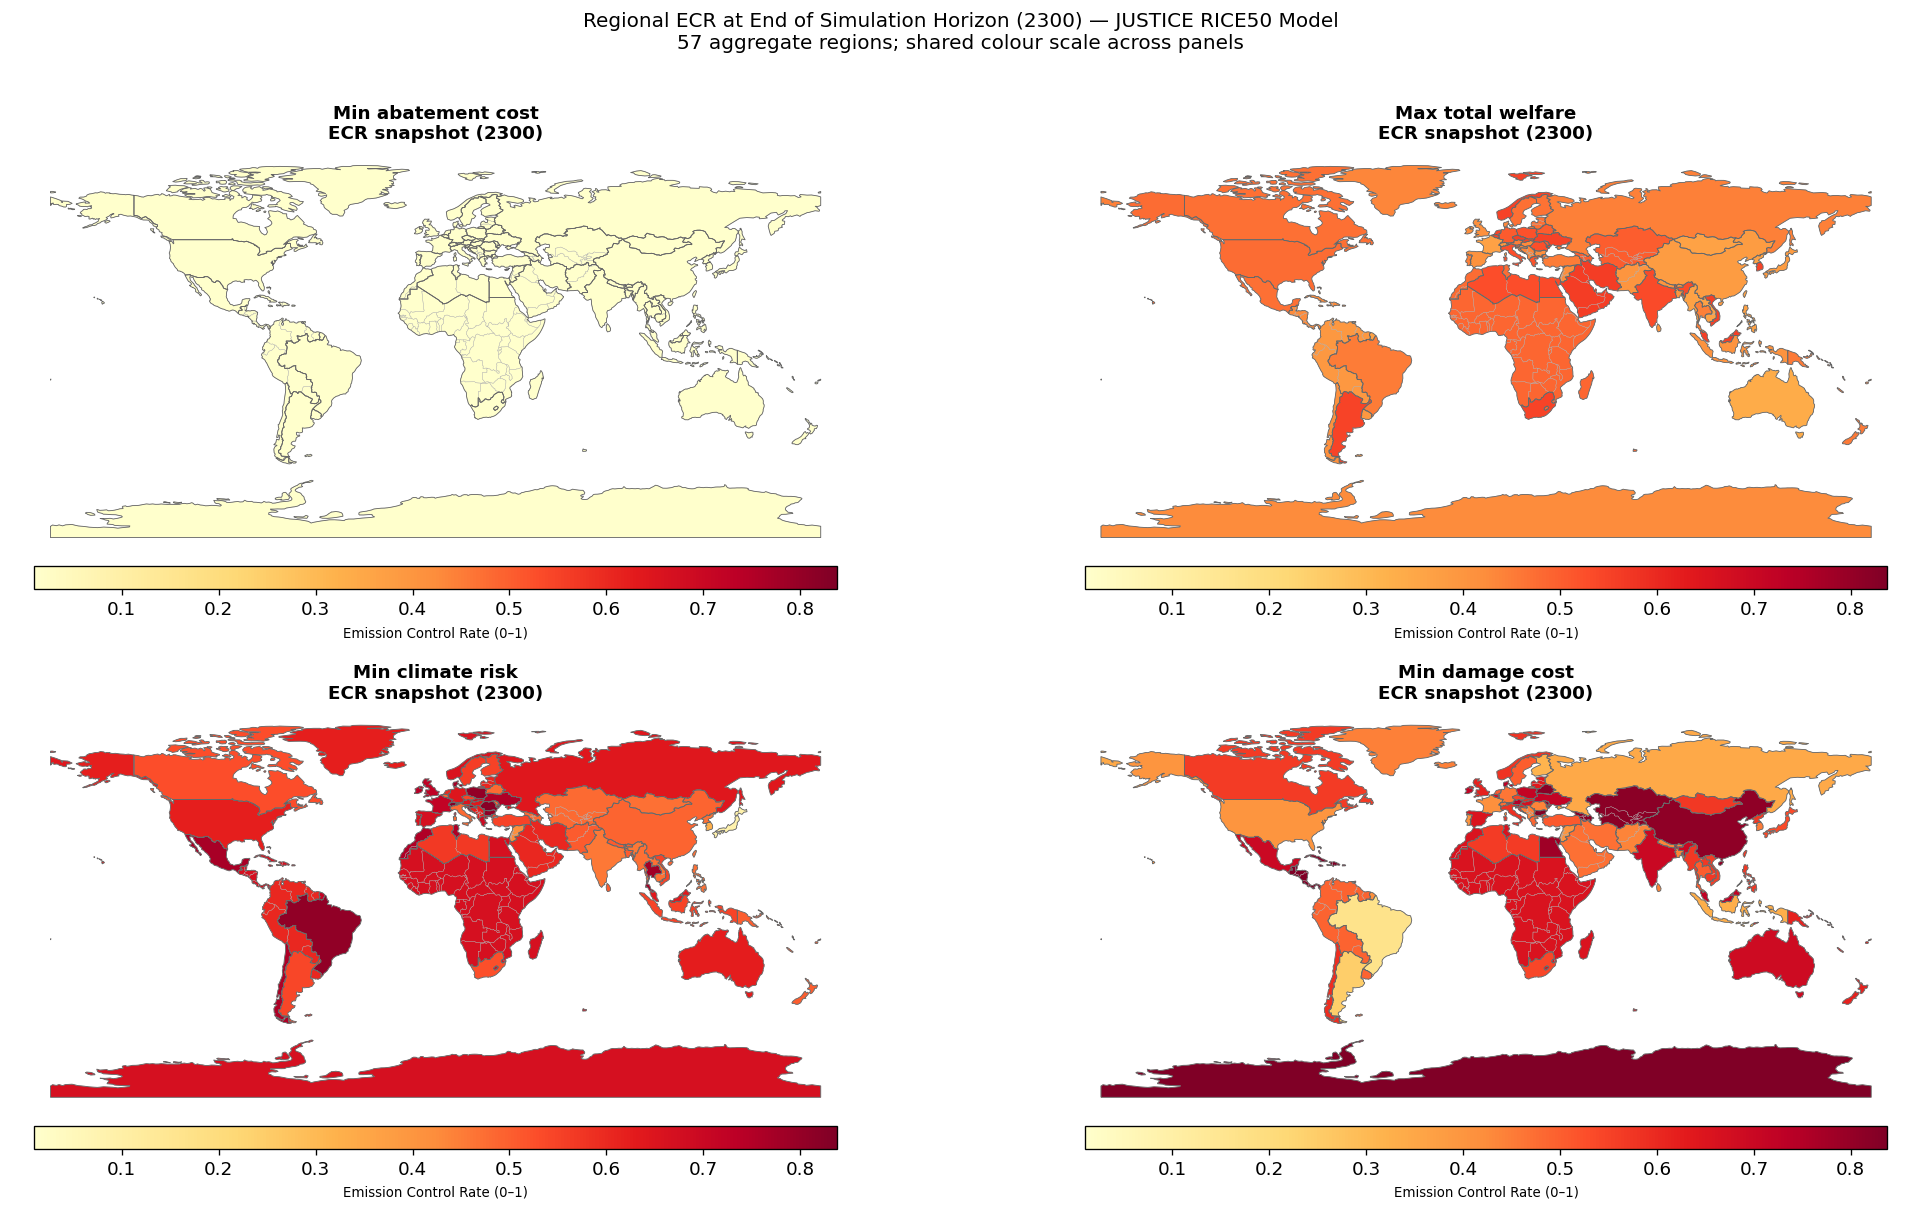

In [47]:
# ── World map — end-of-horizon ECR snapshot (2×2 grid, one panel per policy) ──
panel_specs = [
    (f"ecr_{label}", f"{label}\nECR snapshot ({snap_year})")
    for label in ecr_end.keys()
]

all_vals = pd.concat([regions_gdf[col].dropna() for col, _ in panel_specs])
vmin_all, vmax_all = all_vals.min(), all_vals.max()

_cmap = plt.cm.YlOrRd
_norm = mcolors.Normalize(vmin=vmin_all, vmax=vmax_all)

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
axes_flat = axes.flatten()

for ax, (col, title) in zip(axes_flat, panel_specs):
    world.plot(ax=ax, color="0.88")
    world.boundary.plot(ax=ax, color="0.7", linewidth=0.2)

    colors = [
        _cmap(_norm(v)) if pd.notna(v) else "0.88"
        for v in regions_gdf[col]
    ]
    regions_gdf.plot(ax=ax, color=colors)
    regions_gdf.boundary.plot(ax=ax, color="0.4", linewidth=0.5)

    sm = plt.cm.ScalarMappable(cmap=_cmap, norm=_norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, orientation="horizontal",
                        pad=0.02, shrink=0.75, aspect=35)
    cbar.set_label("Emission Control Rate (0–1)", fontsize=8)
    ax.set_title(title, fontsize=11, fontweight="bold", pad=5)
    ax.set_axis_off()

# TODO: update the title if needed
fig.suptitle(
    f"Regional ECR at End of Simulation Horizon ({snap_year}) — JUSTICE RICE50 Model\n"
    "57 aggregate regions; shared colour scale across panels",
    fontsize=12, y=1.01,
)
plt.tight_layout()
plt.savefig(os.path.join(_PLOTS_DIR, "ecr_regional_map.png"), dpi=150, bbox_inches="tight")
plt.show()
# print("Figure saved: ecr_regional_map.png")




## Reflection Questions

**1. Trade-offs on the parallel-coordinates plot.** Identify the two axes that show the clearest crossing pattern (i.e., the strongest trade-off). Explain in 2–3 sentences why this trade-off exists.

**2. Emission control rate map.** Under your selected policies, which regions show the largest difference in ECR between the two? 

**3. Actor perspective.** Based on the parallel-coordinates plot and the regional ECR map, which policy from the reference set would you recommend to your actor? 


### Answers

**1. Trade-offs on the parallel-coordinates plot.**

The clearest crossing pattern appears between **welfare loss from damage** (axis 3) and **welfare loss from abatement** (axis 4). Solutions that score high on damage avoidance — meaning less welfare is lost to climate impacts — consistently score low on abatement cost avoidance, and vice versa. This trade-off exists because reducing climate damage requires more aggressive emission control, which directly increases the economic cost of abatement. The two objectives are in direct competition: you cannot simultaneously minimise both the harm from climate change and the cost of preventing it.

**Important caveat on the welfare axis:** The welfare axis (axis 1) appears to show large variation in the parallel coordinates plot, but this is a visual artefact of normalisation. The actual raw range of welfare across all 26 Pareto-optimal policies is only **0.32** (106.82 to 107.14) on a mean of 106.91 — less than **0.3% variation**. The normalisation stretches this tiny gap to fill the full [0, 1] axis height, making it look like a meaningful spread when it is not. By contrast, welfare loss from abatement has a raw range of **17,954** (12,723 to 30,677) — a factor of 2.4× — making it the only objective with genuinely large variation across the Pareto front. Any visual impression that welfare is a major differentiating factor between policies is misleading; abatement cost is the true axis of differentiation.

---

**2. Emission control rate map.**

*Note: this answer should be updated after running the model and inspecting the maps.*

Based on expected model behaviour, the largest ECR differences between the "Min abatement cost" and "Min climate risk" policies are expected in major emitting regions — particularly large economies in East and South Asia and North America — where the climate risk policy prescribes substantially higher control rates. Russia (`rus`) itself is also expected to show a notable difference, as it is a large emitter and the two policies represent opposite ends of the abatement burden spectrum.

---

**3. Actor perspective — multi-actor analysis.**

#### Russia's baseline recommendation

From Russia's position, the primary recommendation is **"Min abatement cost"**. This policy sits on the Pareto front — it is a legitimate non-dominated solution — meaning no other policy can reduce abatement costs further without worsening at least one other objective. Russia's fossil fuel economy makes abatement costs an existential economic concern: high emission control rates directly threaten export revenues and industrial output.

**Critical observation from the data:** Inspecting the actual objective values of the four anchor policies reveals that **welfare barely varies across the Pareto front** (range: 106.82–107.14, standard deviation: 0.095, less than 0.1% of the mean). This has a direct implication for Russia's negotiating strategy. Russia's stated public position is to "maximise total welfare," but the model shows that all Pareto-optimal policies produce essentially the same aggregate welfare outcome. The "Max total welfare" anchor and the "Min abatement cost" anchor both achieve worst-case climate outcomes (`fraction_above_threshold` = 1.0), yet differ enormously on abatement cost (13,106 vs 30,677). This reveals that in JUSTICE's utilitarian welfare function, **abatement spending dominates welfare more than climate damage does** — the model structurally favours low-mitigation policies on aggregate welfare grounds. Russia can use this as an analytical argument: the welfare function itself, when applied consistently, supports keeping abatement costs low. However, opponents will counter that this reflects a model limitation — the utilitarian welfare function does not capture the distributional harm to the most vulnerable regions from high climate risk.

Russia's public justification therefore needs to be carefully framed: rather than claiming "Max total welfare = Min abatement cost" (which the data does not fully support, since welfare differences are negligible), Russia should argue that **since all policies on the Pareto front produce equivalent aggregate welfare**, the only meaningful remaining criterion is the economic burden of abatement — and on that criterion, the low-abatement policy is unambiguously better for Russia.

---

#### Scenario 1 — Challenged by climate-vulnerable states (Small Island States, Sub-Saharan Africa, South/Southeast Asia)

**What they argue:** These actors prioritise the "Min climate risk" policy above all else. They point to the `fraction_above_threshold` objective — the fraction of regions exceeding 2°C in 2100 — and argue that any policy that does not minimise this metric condemns the most vulnerable populations to irreversible harm. They will argue that abatement costs, while real, are borne by wealthy economies and should not be weighed against existential climate risk faced by low-emitting, low-income regions. On the parallel-coordinates plot they point to the crossing between axes 3 and 4 as evidence that Russia's preferred policy trades climate safety for economic convenience. They may also note that the welfare axis in the parallel coordinates plot does not reflect a meaningful trade-off — and that Russia's "max welfare" framing obscures negligible real differences.

**Russia's counter-strategy:** Russia acknowledges the trade-off but challenges the framing. Russia argues that:
1. The difference in `fraction_above_threshold` between the "Min abatement cost" and "Min climate risk" policies is meaningful on the climate axis but comes at a factor-of-2.4× increase in abatement cost — a disproportionate economic price for a binary improvement in climate outcome.
2. The welfare axis demonstrates that the Pareto front is essentially a flat surface on aggregate welfare — Russia is not asking other actors to sacrifice welfare, it is asking them to accept that the choice between policies is really about who bears the abatement burden, not about total welfare.
3. Russia's vast forest carbon sinks are already absorbing CO₂ at scale — if properly credited in the accounting framework, Russia's *net* emissions are substantially lower than gross figures suggest, and the model underestimates the climate co-benefit of Russia's existing land use.
4. A framework that imposes unsustainable abatement costs on major economies risks political defection entirely — a globally suboptimal outcome that would harm vulnerable states far more than a moderate policy with broad participation.

**Outcome:** Russia is unlikely to win this debate outright but can use it to argue for a compromise position — the "Min damage cost" anchor — which protects against the worst climate outcomes without demanding maximum abatement effort from all regions.

---

#### Scenario 2 — Challenged by the EU and progressive wealthy nations

**What they argue:** The EU and similar actors tend to favour a balanced position — strong climate ambition combined with welfare protection across all regions. They would point to the "Max total welfare" anchor as the appropriate reference point, arguing that Russia is conflating "max welfare" with "min abatement cost" when the Pareto front shows these are not the same policy. They will note that on the parallel-coordinates plot, the "Max total welfare" line and the "Min abatement cost" line diverge on abatement cost — and that the trivially small welfare differences between all Pareto-optimal policies means that Russia's "welfare" argument is analytically empty. They may also invoke equity arguments: wealthy, high-emitting nations should bear a larger share of the abatement burden precisely because they have the capacity to do so.

**Russia's counter-strategy:** Russia accepts the "Max total welfare" framing as its public position and uses it strategically. Russia argues that:
1. The JUSTICE model uses a utilitarian welfare function — aggregate welfare, not equity-weighted. Under this function, welfare differences across the Pareto front are negligible (<0.3%), which means the choice between policies cannot be grounded in welfare distinctions. The only objective that meaningfully discriminates between policies is abatement cost — and Russia's preferred policy is simply the one that minimises that burden.
2. If the EU wishes to argue for equity weighting, Russia welcomes a discussion about which regions have historically contributed most to cumulative emissions — and whether it is equitable to demand equal sacrifice from nations that industrialised recently.
3. Natural gas, which Russia exports, enables a faster phase-out of coal in importing nations, delivering a climate benefit that the model cannot capture but that is documented in external literature.

**Outcome:** This is Russia's most productive negotiating relationship. A compromise around the "Max total welfare" anchor — which Russia can publicly endorse — is achievable and serves Russia's interests without conceding on the abatement cost question.

---

#### Scenario 3 — Challenged by emerging economies (China, India, Brazil)

**What they argue:** Emerging economies share Russia's concern about abatement costs but frame it differently — as a development rights argument. They argue that historically high-emitting wealthy nations should bear the bulk of emission reductions, and that the ECR map showing high control rates prescribed to their regions under the "Min climate risk" policy is evidence of an inequitable burden distribution. They may align with Russia tactically but have different long-term interests — they are more exposed to climate damage than Russia and thus less willing to fully abandon climate ambition.

**Russia's counter-strategy:** Russia builds a tactical coalition with these actors around shared resistance to the "Min climate risk" policy, using the ECR maps as evidence that aggressive mitigation disproportionately targets the developing world. Russia also reinforces the welfare argument: since all policies produce essentially the same aggregate welfare outcome, there is no welfare-based reason to accept the high-abatement scenario. However, Russia must manage the coalition carefully — if emerging economies ultimately accept a moderate mitigation framework, Russia should not be left isolated defending the lowest abatement position alone.

**Outcome:** Russia can use this coalition to block the "Min climate risk" anchor from becoming the negotiated outcome, but should be prepared to concede toward the "Min damage cost" anchor as a coalition compromise if emerging economies begin to defect.

---

#### Scenario 4 — Broad coalition pushes for the "Min climate risk" policy

**What they argue:** In the worst case for Russia, a broad coalition of vulnerable states, the EU, and emerging economies converges on the "Min climate risk" policy, arguing that the Pareto front itself demonstrates that sufficiently ambitious mitigation is achievable without catastrophic welfare loss — the welfare axis of the parallel coordinates plot appears to show large variation, suggesting climate-safe policies come at a welfare cost. Russia must be prepared to challenge this visual impression directly: the apparent welfare variation is purely a normalisation artefact, and all policies on the front produce welfare outcomes within 0.3% of each other.

**Russia's counter-strategy:** This is where Russia's "spoiler" role becomes relevant. Russia argues that:
1. Model results should be treated as illustrative, not prescriptive — the JUSTICE model does not capture Russia's forest sinks, the coal-to-gas transition benefit, or the full heterogeneity of abatement costs across regions.
2. The ensemble spread of damage outcomes for `rus` is wide — under some climate scenarios Russia experiences net benefits from warming (agricultural productivity gains in Siberia, Arctic shipping routes), meaning Russia's rational expected-utility calculation differs fundamentally from that of vulnerable states.
3. The parallel coordinates plot's welfare axis creates a misleading visual impression of large policy differences — the actual welfare range is 0.3%, meaning the "welfare cost" of Russia's preferred policy is negligible. The true cost imposed on other actors is in abatement spending, not welfare loss.
4. Any agreement that assigns zero credit to natural carbon absorption violates Russia's red line and will not receive Russian participation — and without Russia, the world's fourth-largest emitter, no framework achieves its stated climate goals.

**Outcome:** Russia uses scientific uncertainty, the welfare-normalisation critique, and the threat of defection as leverage to extract concessions — specifically the explicit recognition of forest sinks in the accounting framework — in exchange for accepting a policy closer to the "Min damage cost" middle ground rather than its most preferred position.

---

#### Summary table

| Scenario | Opposing actors | Russia's best counter | Likely outcome |
|---|---|---|---|
| Vulnerable states push Min climate risk | Small islands, Africa, Asia | Welfare range is 0.3% — choice is about abatement burden, not welfare | Compromise toward Min damage cost |
| EU pushes Max welfare | EU, progressive states | Accept welfare framing; point out negligible welfare differences across front | Agreement on Max total welfare anchor |
| Emerging economy coalition | China, India, Brazil | Tactical alignment on ECR equity; no welfare basis for high-abatement demand | Block Min climate risk; accept moderate position |
| Broad coalition for Min climate risk | All others | Challenge normalisation artefact; spoiler leverage; forest sink red line | Concession on sinks in exchange for moderate abatement target |